# Tutorial 2 — the real thing: how often do players challenge, and how often are they right?

In Tutorial 1 you built a toy world where the challenger *perceives* the pitch with noise σ. Now use the real 2026 data:
every eligible called pitch (about 270,000 through mid-August), with the umpire's original call, the true miss distance to the
ABS zone (which we reconstructed and validated against the ABS verdicts to 99.7%), whether the pitch was challenged, and the outcome.

**Goal:** reproduce one curve yourself — P(challenge | true margin) — for batters and for catchers, and read σ off it.

Data: `opps_2026.parquet` from the repo's `data` release
(https://github.com/AyanArora29/use-it-or-lose-it/releases/download/data/opps_2026.parquet) — put it in `data/derived/`.
One row per eligible called pitch. Key columns:

| column | meaning |
|---|---|
| `orig` | the umpire's ORIGINAL call: `S` called strike, `B` called ball |
| `x_margin` | true margin in the challenger's favour, inches (> 0 ⇒ the umpire was wrong ⇒ a challenge would succeed) |
| `truth` | 1 if the call was wrong |
| `challenged`, `isOverturned`, `role` | did anyone challenge; was it overturned; who challenged (batter / catcher / pitcher) |
| `tokens` | challenges the eligible team had in hand before the pitch |
| `inning`, `balls`, `strikes`, `outs`, `bases_idx`, `sd_home` | game state |
| `g` | win-probability swing if the call is flipped (0–1 scale; ×100 = points) |


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
o = pd.read_parquet("../data/derived/opps_2026.parquet")
o = o[(o["pos_pitcher"] == 0) & (o["tokens"] >= 1)]          # a team without a challenge can't challenge
o["side"] = np.where(o["orig"] == "S", "batting team", "fielding team")
print(len(o), "eligible called pitches;", int(o["challenged"].sum()), "challenges;",
      f"{o.loc[o.challenged==1,'isOverturned'].mean():.3f} overturned")
o.groupby("side")[["challenged", "truth"]].mean().round(4)

251067 eligible called pitches; 7871 challenges; 0.537 overturned


,challenged,truth
side,,
batting team,0.0447,0.1103
fielding team,0.0250,0.0475


## 1. The curve
Bin the true margin and compute the share of pitches challenged in each bin — separately for the two sides.
(Points sized by how many pitches are in the bin.)

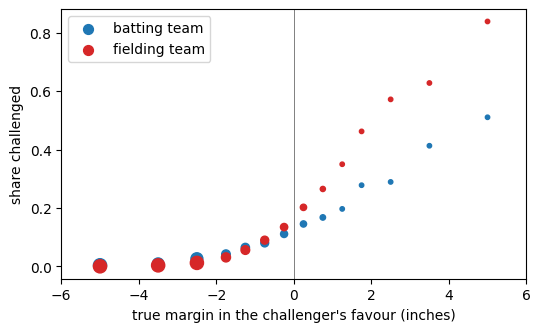

In [2]:
bins = [-30, -6, -4, -3, -2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2, 3, 4, 6, 40]
o["xb"] = pd.cut(o["x_margin"], bins)
mid = {iv: (max(iv.left, -7) + min(iv.right, 7)) / 2 for iv in o["xb"].cat.categories}
o["xmid"] = o["xb"].map(mid).astype(float)
curve = o.groupby(["side", "xmid"], observed=True).agg(n=("challenged", "size"), p_challenge=("challenged", "mean")).reset_index()
fig, ax = plt.subplots(figsize=(6, 3.5))
for side, col in (("batting team", "tab:blue"), ("fielding team", "tab:red")):
    c = curve[(curve["side"] == side) & (curve["n"] >= 30)]
    ax.scatter(c["xmid"], c["p_challenge"], s=np.clip(c["n"] / 150, 10, 90), color=col, label=side)
ax.axvline(0, color="grey", lw=0.7); ax.set_xlim(-6, 6)
ax.set_xlabel("true margin in the challenger's favour (inches)"); ax.set_ylabel("share challenged"); ax.legend(); plt.show()

**Read the picture.** If players saw the pitch perfectly, the curve would be a step: 0 to the left of zero, 1 to the right.
It isn't — it rises slowly across several inches. That slope *is* the perception noise from Tutorial 1.

## 2. Fit σ and τ
Tutorial 1's model: challenge iff perceived miss `m = x + ε > τ`, `ε ~ N(0, σ²)`  ⇒  P(challenge | x) = Φ((x − τ)/σ).
That's a probit regression of `challenged` on `x_margin`: slope a = 1/σ, intercept b = −τ/σ.

In [3]:
from scipy.stats import norm
from scipy.optimize import minimize
def fit_probit(x, y):
    def nll(th):
        a, b = th; P = np.clip(norm.cdf(a * x + b), 1e-12, 1 - 1e-12)
        return -(y * np.log(P) + (1 - y) * np.log(1 - P)).sum()
    r = minimize(nll, [0.5, -1.0], method="Nelder-Mead")
    a, b = r.x
    return 1 / a, -b / a
for side in ("batting team", "fielding team"):
    s = o[o["side"] == side]
    sigma, tau = fit_probit(s["x_margin"].values, s["challenged"].values.astype(float))
    print(f"{side:14s}: sigma = {sigma:.2f} in, tau = {tau:.2f} in")

batting team  : sigma = 3.25 in, tau = 3.83 in


fielding team : sigma = 2.03 in, tau = 2.00 in


## 3. Are they right when they challenge?
Given a challenge, the overturn rate at each margin is (almost) deterministic — the pitch either was or wasn't outside the zone.
The interesting number is the overturn rate *averaged over the challenges players actually made*: it tells you how far into
"coin-flip territory" they go.

In [4]:
ch = o[o["challenged"] == 1]
print(ch.groupby("side")["isOverturned"].agg(["size", "mean"]).round(3))
print(ch.groupby(["side", pd.cut(ch["inning"], [0, 3, 6, 8, 20], labels=["1-3", "4-6", "7-8", "9+"])], observed=True)["isOverturned"].mean().unstack().round(3))

               size   mean
side                      
batting team   3615  0.486
fielding team  4256  0.581
inning           1-3    4-6    7-8     9+
side                                     
batting team   0.520  0.512  0.480  0.391
fielding team  0.664  0.586  0.555  0.432


## Questions (write 3–5 sentences each)
1. Batters' σ is bigger than catchers'. Give two different explanations — one about *eyes* (where they stand, what they're doing when the pitch arrives) and one about *incentives or rules* (who is allowed to challenge on each team, and what a batter is thinking about at 3-2).
2. The overturn rate falls from the early innings to the 9th. Tutorial 1 says a lower success rate late can be *rational*. Explain why in one paragraph, using the phrase "use it or lose it".
3. Change the fit to use only pitches with `tokens == 2` and then only `tokens == 1`. Do τ or σ move? Which one *should* move if players were following the dynamic program, and why?
